У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns
from darts import TimeSeries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('drive/MyDrive/Colab Notebooks/train_.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

In [ ]:
print(data.index[:10])
print(pd.infer_freq(data.index))

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10'],
              dtype='datetime64[ns]', name='date', freq=None)
None


In [ ]:
data[:10]

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [ ]:
subset = data[(data["store"] == 1) & (data["item"] == 1)]


In [ ]:
import plotly.express as px

fig = px.line(subset, x=subset.index, y="sales",
              title="Продажі: магазин 1, товар 1")

fig.update_layout(template="simple_white",
                  font=dict(size=18),
                  width=650, height=400,
                  title_x=0.5)
fig.show()


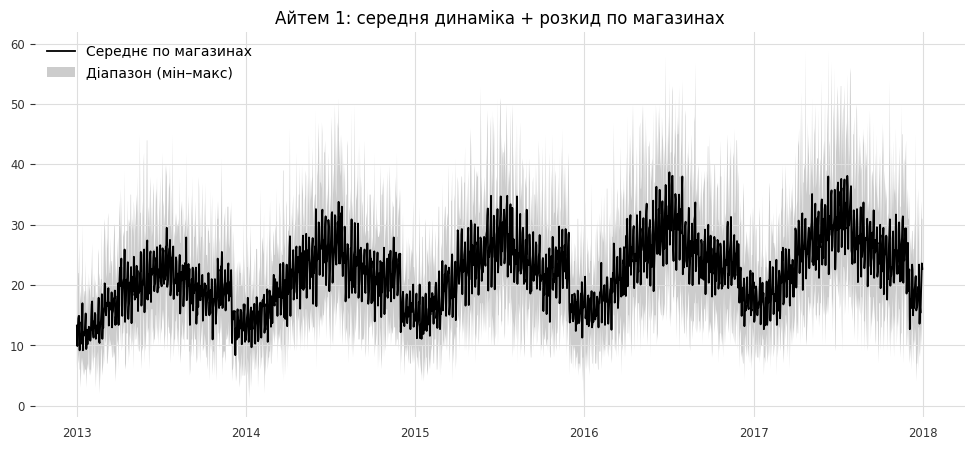

In [ ]:
subset = data[data["item"] == 1].groupby(["date","item"])["sales"].agg(["mean","min","max"]).reset_index()

plt.figure(figsize=(12,5))
plt.plot(subset["date"], subset["mean"], label="Середнє по магазинах")
plt.fill_between(subset["date"], subset["min"], subset["max"], alpha=0.2, label="Діапазон (мін–макс)")
plt.title("Айтем 1: середня динаміка + розкид по магазинах")
plt.legend()
plt.show()


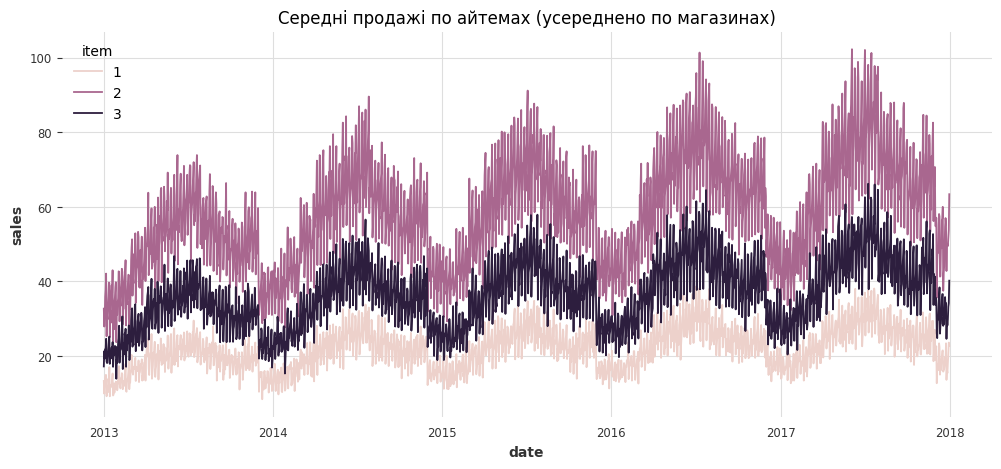

In [ ]:
items_to_plot = [1, 2, 3]
subset = data[data["item"].isin(items_to_plot)].groupby(["date","item"])["sales"].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=subset, x="date", y="sales", hue="item")
plt.title("Середні продажі по айтемах (усереднено по магазинах)")
plt.show()


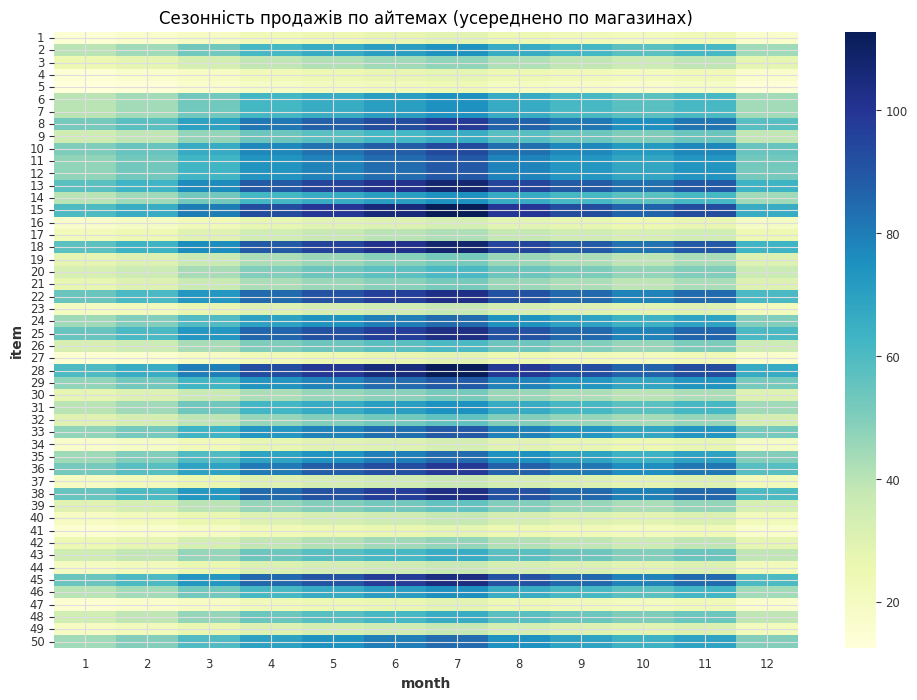

In [ ]:
data["month"] = data.index.month
heatmap_data = data.groupby(["item","month"])["sales"].mean().unstack()

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Сезонність продажів по айтемах (усереднено по магазинах)")
plt.show()


**висновок**

На графіках видно чітку сезонність та зростання продажів у літні місяці і спадання в кінці року, а також невелике зростання продажів за роками(помірний тренд) та те, що деякі магазини продають набагато більше товару а деякі набагато менше.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [ ]:
df_additive = subset.copy(deep=True)

In [ ]:
df_additive.head()

,date,item,sales
0,2013-01-01,1,13.3
1,2013-01-01,2,32.7
2,2013-01-01,3,17.2
3,2013-01-02,1,9.9
4,2013-01-02,2,27.9


In [ ]:
df_additive['date'] = pd.to_datetime(df_additive['date'])
df_additive.set_index('date', inplace=True)

In [ ]:
# рахуємо тренд згладжуючи ряд з річним вікном розміром 13
df_additive["trend"] = df_additive["sales"].rolling(window=13, center=True).mean()

In [ ]:
# віднімаємо тренд з даних
df_additive["detrended"] = df_additive["sales"] - df_additive["trend"]

In [ ]:
# рахуємо сезонну складову як середнє значення ряду пілся віднімання тренду
df_additive["month"] = df_additive.index.month
df_additive["seasonality"] = df_additive.groupby("month")["detrended"].transform("mean")

In [ ]:
# обчислюємо залишок як все, що ми не змогли пояснити сезонністю
df_additive["resid"] = df_additive["detrended"] - df_additive["seasonality"]

In [ ]:
df_additive.head(15)

,item,sales,trend,detrended,month,seasonality,resid
date,,,,,,,
2013-01-01,1,13.3,NaN,NaN,1,-0.03873,NaN
2013-01-01,2,32.7,NaN,NaN,1,-0.03873,NaN
2013-01-01,3,17.2,NaN,NaN,1,-0.03873,NaN
2013-01-02,1,9.9,NaN,NaN,1,-0.03873,NaN
2013-01-02,2,27.9,NaN,NaN,1,-0.03873,NaN
2013-01-02,3,21.3,NaN,NaN,1,-0.03873,NaN
2013-01-03,1,12.7,20.907692,-8.207692,1,-0.03873,-8.168963
2013-01-03,2,30.4,22.784615,7.615385,1,-0.03873,7.654114
2013-01-03,3,19.3,21.938462,-2.638462,1,-0.03873,-2.599732


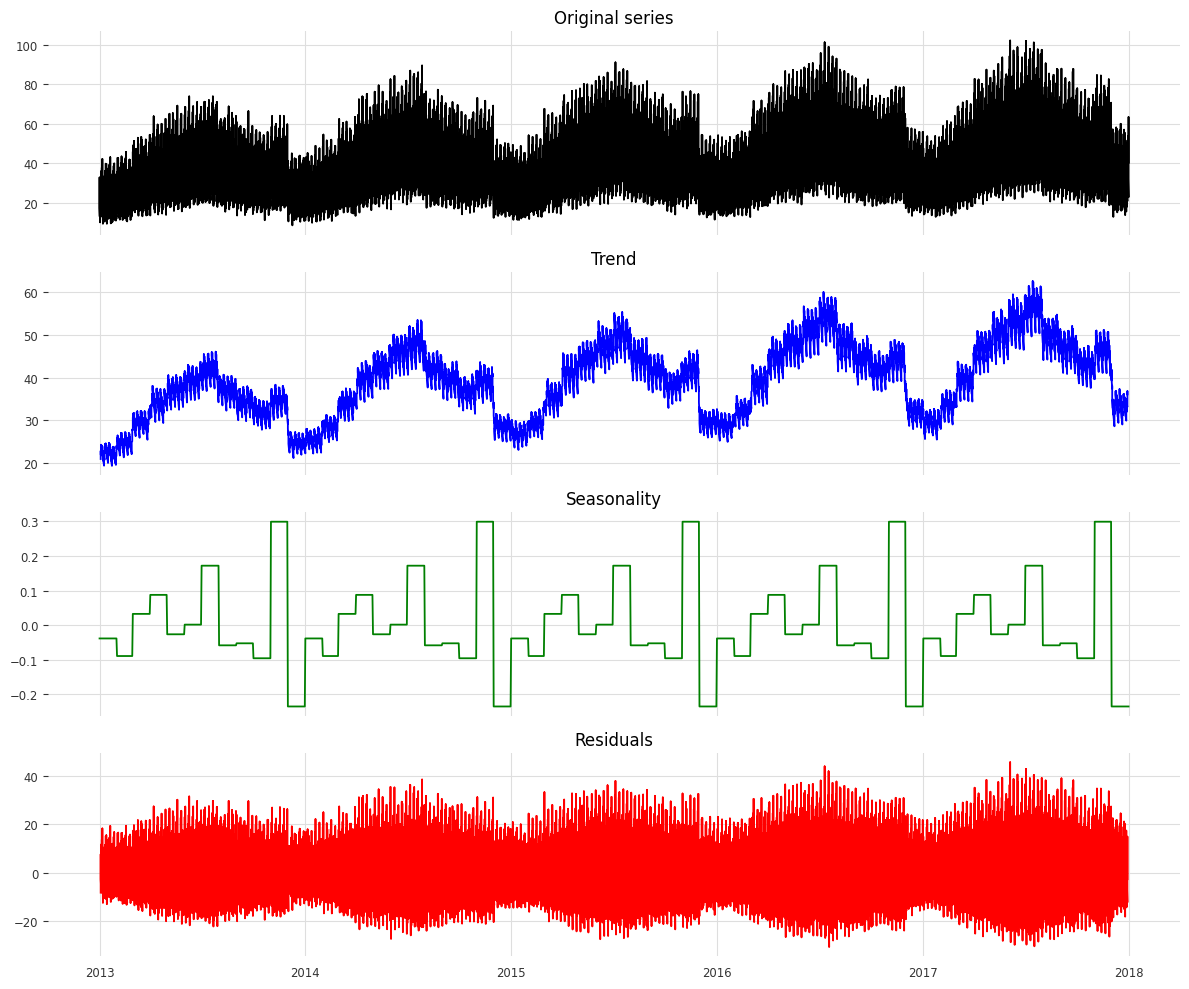

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# 1. Оригінальний ряд
axes[0].plot(df_additive.index, df_additive["sales"], label="Original", color="black")
axes[0].set_title("Original series")

# 2. Тренд
axes[1].plot(df_additive.index, df_additive["trend"], label="Trend", color="blue")
axes[1].set_title("Trend")

# 3. Сезонність
axes[2].plot(df_additive.index, df_additive["seasonality"], label="Seasonality", color="green")
axes[2].set_title("Seasonality")

# 4. Залишок
axes[3].plot(df_additive.index, df_additive["resid"], label="Residuals", color="red")
axes[3].set_title("Residuals")

plt.tight_layout()
plt.show()


ресідуали мають деякий патерн, це не ок

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [ ]:
df_additive = df_additive.groupby("date").agg({"sales": "sum"}).sort_index()

In [ ]:
df_additive.head()

,sales
date,
2013-01-01,63.2
2013-01-02,59.1
2013-01-03,62.4
2013-01-04,72.2
2013-01-05,74.3


In [ ]:
print(df_additive.index[:10])
print(pd.infer_freq(df_additive.index))


DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10'],
              dtype='datetime64[ns]', name='date', freq=None)
D


In [ ]:
series = TimeSeries.from_dataframe(df_additive, time_col=None, value_cols="sales", fill_missing_dates=True, freq=None )

In [ ]:
series.head()

<TimeSeries (date: 5, component: 1, sample: 1)> Size: 40B
array([[[63.2]],

       [[59.1]],

       [[62.4]],

       [[72.2]],

       [[74.3]]])
Coordinates:
  * date       (date) datetime64[ns] 40B 2013-01-01 2013-01-02 ... 2013-01-05
  * component  (component) object 8B 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

<Axes: xlabel='date'>

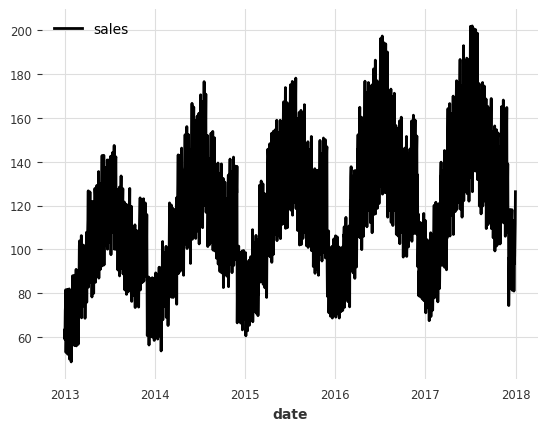

In [ ]:
series.plot()

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

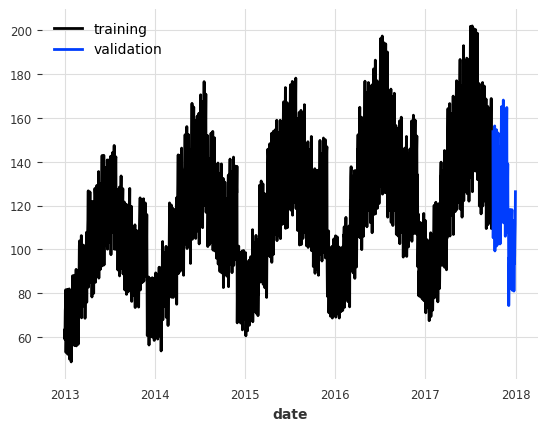

In [ ]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

In [ ]:
print(type(series))
print(dir(series)[:200])   # подивитись доступні методи/атрибути


<class 'darts.timeseries.TimeSeries'>
['__abs__', '__add__', '__class__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__pow__', '__radd__', '__reduce__', '__reduce_ex__', '__repr__', '__rmul__', '__round__', '__rsub__', '__rtruediv__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__truediv__', '__weakref__', '_assert_deterministic', '_assert_stochastic', '_assert_univariate', '_attrs', '_bottom_level_components', '_components', '_extract_values', '_fill_missing_dates', '_freq', '_freq_str', '_get_agg_dims', '_get_axis', '_get_first_timestamp_after', '_get_last_timestamp_before', '_has_datetime_index', '_observed_freq_datetime_index', '_observed_freq_integer_index', '_raise_if_not_within

In [ ]:
# Показати кількість компонент
print("n_components:", series.n_components)
print("shape:", series.shape)

if series.n_components == 1:
    print("уніваріантний")
else:
    print("мультиваріантний")


n_components: 1
shape: (1826, 1, 1)
уніваріантний


<Figure size 1000x600 with 0 Axes>

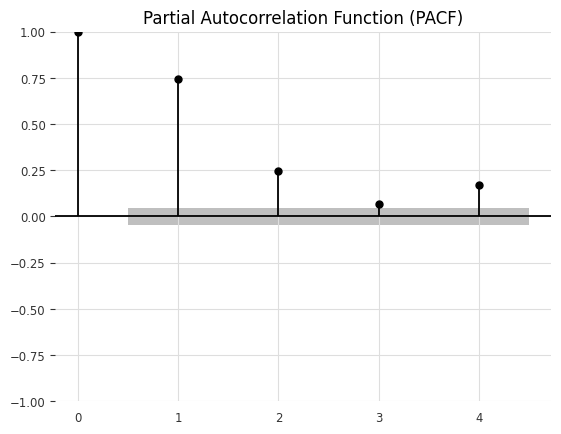

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
s = series.to_series()
# Візуалізація часткової автокореляційної функції (PACF)
plt.figure(figsize=(10, 6))
plot_pacf(s, lags=min(4, len(s)-1), method='ywm')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

Перший лаг значущий — значення сьогодні корелює із значенням вчора після вилучення впливу проміжних лагів.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

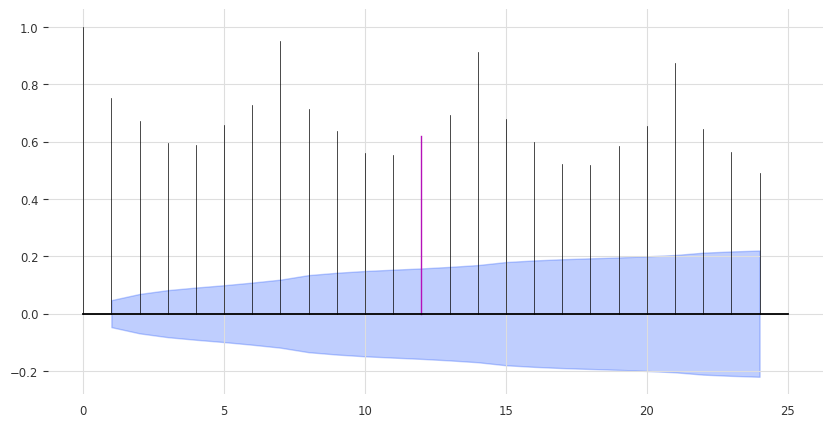

In [ ]:
from darts.utils.statistics import plot_acf, check_seasonality

plot_acf(train, m=12, alpha=0.05, max_lag=24)

In [ ]:
for m in range(2, 25):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.
There is seasonality of order 14.
There is seasonality of order 21.


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

<Axes: xlabel='date'>

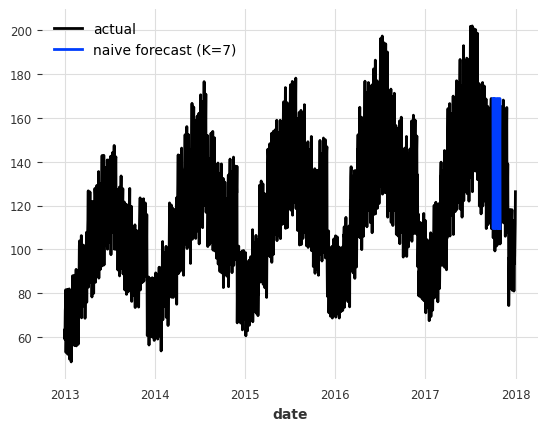

In [ ]:
from darts.models import NaiveSeasonal

naive_model = NaiveSeasonal(K=7)
naive_model.fit(train)
naive_forecast = naive_model.predict(30)

series.plot(label="actual")
naive_forecast.plot(label="naive forecast (K=7)")

<Axes: xlabel='date'>

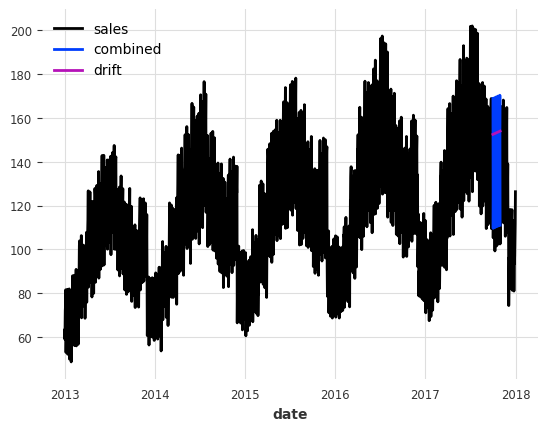

In [ ]:
from darts.models import NaiveDrift

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(30)

combined_forecast = drift_forecast + naive_forecast - train.last_value()

series.plot()
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [ ]:
from darts.metrics import mape

h = len(val)

seasonal_forecast = naive_model.predict(h)
drift_forecast = drift_model.predict(h)

combined_forecast_val = drift_forecast + seasonal_forecast - train.last_value()

print(f"MAPE combined: {mape(val, combined_forecast_val):.2f}%.")

MAPE combined: 18.61%.


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

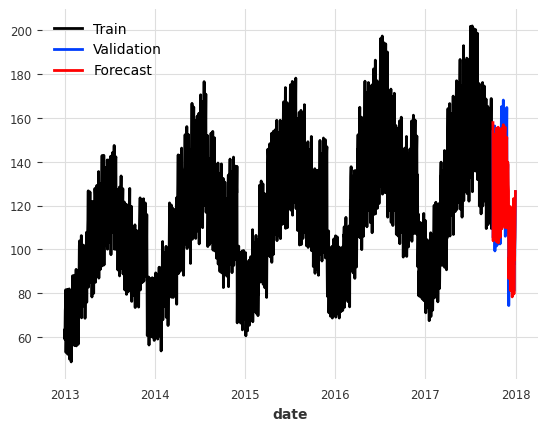

MAPE: 3.83582238263223
RMSE: 6.363484087534701
MAE: 4.54856535870096


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, rmse, mae

# Функція для ознак дати
def enrich_with_date_features(df):
    dt_index = df.index
    df["year"]       = dt_index.year
    df["quarter"]    = dt_index.quarter
    df["month"]      = dt_index.month
    df["dayofweek"]  = dt_index.dayofweek
    df["dayofyear"]  = dt_index.dayofyear
    df["sin_day"]    = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["cos_day"]    = np.cos(2 * np.pi * df["dayofyear"] / 365)
    return df

# Перетворення TimeSeries в DataFrame
train_df = pd.DataFrame(train.values(), index=train.time_index, columns=train.components)
val_df   = pd.DataFrame(val.values(),   index=val.time_index,   columns=val.components)

# Додавання ознак дати
train_df = enrich_with_date_features(train_df)
val_df   = enrich_with_date_features(val_df)

# Розділення на таргет і ознаки
train_target      = TimeSeries.from_dataframe(train_df, value_cols="sales")
train_covariates  = TimeSeries.from_dataframe(train_df.drop(columns=["sales"]))
val_target        = TimeSeries.from_dataframe(val_df, value_cols="sales")
val_covariates    = TimeSeries.from_dataframe(val_df.drop(columns=["sales"]))

# Масштабування
target_scaler = Scaler()
cov_scaler    = Scaler()
train_target_scaled     = target_scaler.fit_transform(train_target)
val_target_scaled       = target_scaler.transform(val_target)
train_covariates_scaled = cov_scaler.fit_transform(train_covariates)
val_covariates_scaled   = cov_scaler.transform(val_covariates)

# Побудова моделі
model = XGBModel(
    lags=60,
    output_chunk_length=30,
    lags_future_covariates=(0, 30),
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

# Тренування
model.fit(train_target_scaled, future_covariates=train_covariates_scaled)

# Прогноз
forecast_scaled = model.predict(n=len(val_target_scaled), future_covariates=val_covariates_scaled)
forecast = target_scaler.inverse_transform(forecast_scaled)

# Вирівнювання індексів
forecast = forecast.slice_intersect(val_target)
val_     = val_target.slice_intersect(forecast)

# Візуалізація
train_target.plot(label="Train")
val_target.plot(label="Validation")
forecast.plot(label="Forecast", color="red")
plt.legend()
plt.show()

# Метрики
print("MAPE:", mape(val_, forecast))
print("RMSE:", rmse(val_, forecast))
print("MAE:", mae(val_, forecast))


**Висновок**\
MAPE: 3.83% — дуже точний прогноз, середня помилка менше 4%.\
RMSE: 6.36 — середньоквадратична помилка в межах норми.\
MAE: 4.55 — середня абсолютна помилка, яка свідчить про стабільність моделі.\
Ці значення свідчать про те, що модель добре вловила структуру даних, сезонність і тренди, і здатна давати надійні прогнози на місяць вперед.



11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

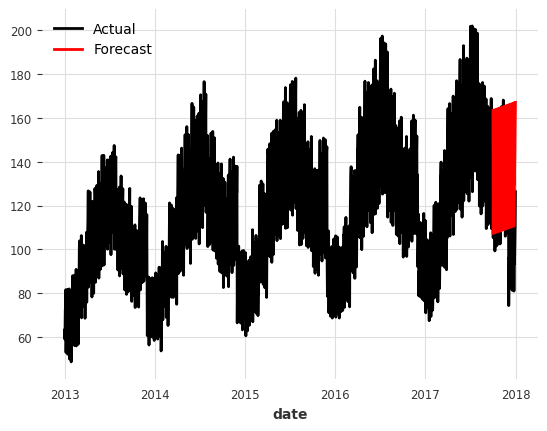

model ExponentialSmoothing() obtains MAPE: 16.21%


In [ ]:
def plot_results(series, forecast):
  # Візуалізація результатів
  series.plot(label='Actual')
  forecast.plot(label='Forecast', color='red')
  plt.legend()
  plt.show()

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  plot_results(series, forecast)
  eval_forecast(model, val, forecast);

model = ExponentialSmoothing()
fit_and_plot(model, series, train, val)

**Висновок**

Модель ExponentialSmoothing показала базовий рівень точності, але її результат (MAPE ≈ 16.21%) є недостатнім для точного прогнозування продажів.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



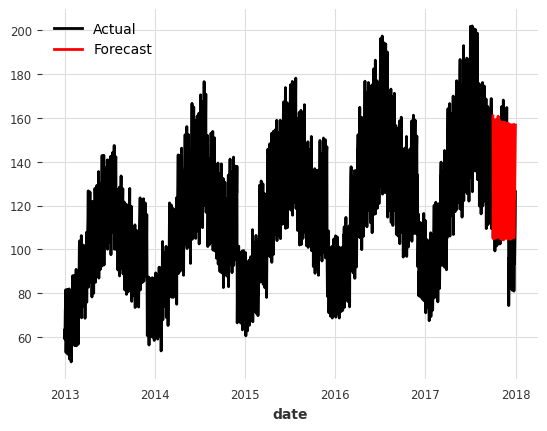

model ARIMA(p=30, q=30) obtains MAPE: 14.05%


In [ ]:
from darts.models import ARIMA

# Побудова та тренування моделі ARIMA
model = ARIMA(p=30, d=1, q=30)
fit_and_plot(model, series, train, val)

**Висновок**

У конфігурації p=30, q=30 модель враховує до 30 попередніх значень ряду та 30 лагів помилки, що дозволяє їй вловлювати довгострокові залежності.

Помилка понад 10% свідчить про середню точність моделі.

ARIMA не змогла повністю адаптуватися до складної структури даних, зокрема до тижневої сезонності та можливих зовнішніх факторів.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=1, max_p=14, start_q=1, max_q=14, d=1, seasonal=True, season_length=7, stepwise=True)

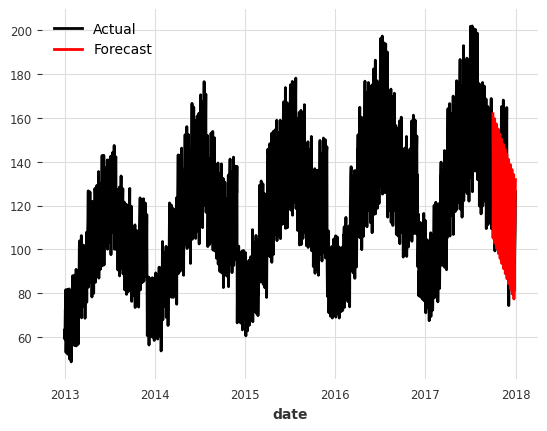

MAPE: 9.065089021721912
RMSE: 13.661237196864862
MAE: 11.135048047436676


In [ ]:
from darts.models import AutoARIMA

model = AutoARIMA(
    start_p=1,
    max_p=14,
    start_q=1,
    max_q=14,
    d=1,
    seasonal=True,
    season_length=7,
    stepwise=True
)

model.fit(train)

display(model)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
plot_results(series, forecast)

forecast_ = forecast.slice_intersect(val)
val_ = val.slice_intersect(forecast_)

# Обчислення метрик
print("MAPE:", mape(val_, forecast_))
print("RMSE:", rmse(val_, forecast_))
print("MAE:", mae(val_, forecast_))

**Висновок**

Модель AutoARIMA показала значно кращу точність, знизивши MAPE з 14.05% до 9.07%.

Це означає, що середня відносна помилка зменшилась майже на третину, що є суттєвим покращенням для задачі прогнозування продажів.

також має нижчі значення RMSE та MAE, що свідчить про менші абсолютні та квадратичні відхилення. Це означає, що модель не лише точніша в середньому, але й менш схильна до великих помилок.

Вона краще врахувала тижневу сезонність, адаптувалась до тренду і показала стабільні результати.

Але на разі XGBoost залишається найкращою.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsk0h9rv3/2bpbywjd.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsk0h9rv3/rwkedxdm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=67104', 'data', 'file=/tmp/tmpsk0h9rv3/2bpbywjd.json', 'init=/tmp/tmpsk0h9rv3/rwkedxdm.json', 'output', 'file=/tmp/tmpsk0h9rv3/prophet_modelk4y5w37_/prophet_model-20251019103749.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:37:49 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:37:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


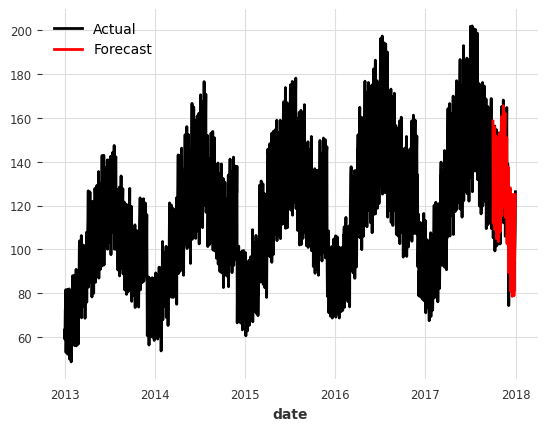

MAPE: 5.043913487064105
RMSE: 7.660983309222309
MAE: 5.8903528978624395


In [ ]:
from darts.models import Prophet

# Побудова та тренування моделі Prophet
model = Prophet()
model.fit(train)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

forecast_ = forecast.slice_intersect(val)
val_ = val.slice_intersect(forecast_)

# Обчислення метрик
print("MAPE:", mape(val_, forecast_))
print("RMSE:", rmse(val_, forecast_))
print("MAE:", mae(val_, forecast_))

**Висновок**

Модель Prophet продемонструвала найкращу якість прогнозу у нашій задачі, з найнижчими значеннями MAPE, RMSE та MAE. Вона ефективно врахувала тижневу сезонність і тренди, що дозволило їй перевершити як класичну ARIMA, так і AutoARIMA і XGBoost

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

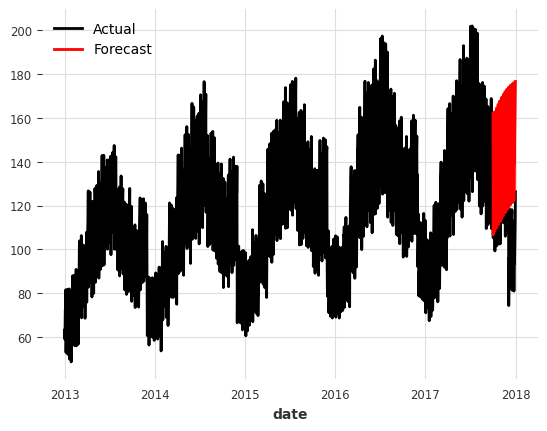

MAPE: 20.76124787976084
RMSE: 29.955969720127513
MAE: 22.056775957568092


In [ ]:
from darts.models import RNNModel

# Побудова та тренування моделі LSTM
model = RNNModel(
    model='LSTM',
    input_chunk_length=14,      # модель бачить 2 тижні історії
    output_chunk_length=7,      # прогнозує на 1 тиждень
    n_epochs=300                # достатньо для стабільного навчання
)

model.fit(train)

# Прогнозування на період валідації
forecast = model.predict(n=len(val))

# Візуалізація результатів
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()


forecast_ = forecast.slice_intersect(val)
val_ = val.slice_intersect(forecast_)

# Обчислення метрик
print("MAPE:", mape(val_, forecast_))
print("RMSE:", rmse(val_, forecast_))
print("MAE:", mae(val_, forecast_))

**Висновок**

MAPE понад 20% свідчить про низьку точність моделі.
RMSE і MAE значно вищі, ніж у Prophet та AutoARIMA, що вказує на великі відхилення між прогнозом і фактичними значеннями.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsk0h9rv3/c0ddsl__.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpsk0h9rv3/hsmue9za.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=21316', 'data', 'file=/tmp/tmpsk0h9rv3/c0ddsl__.json', 'init=/tmp/tmpsk0h9rv3/hsmue9za.json', 'output', 'file=/tmp/tmpsk0h9rv3/prophet_modeljanujefy/prophet_model-20251019112300.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:23:00 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:23:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
historical forecasts:   0%|          | 0/12 [00:00<?, ?it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True 

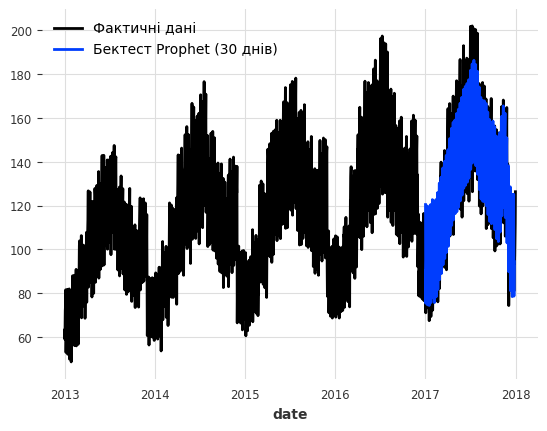

MAPE = 5.23%


In [ ]:
from functools import reduce

# Найкраща модель
model = Prophet()
model.fit(train)

# Бектест: прогноз на 30 днів, кроком 30 днів, протягом останнього року
historical_fcast = model.historical_forecasts(
    series=series,
    start=pd.Timestamp("2017-01-01"),
    forecast_horizon=30,
    stride=30,
    last_points_only=False,
    verbose=True
)

# Об'єднання списку прогнозів у один TimeSeries
historical_fcast_ts = reduce(lambda a, b: a.append(b), historical_fcast)

# Вирізання фактичних значень для періоду бектесту
start_bt = pd.Timestamp("2017-01-01")
end_bt = historical_fcast_ts.end_time()
actual_bt = series.slice(start_bt, end_bt)

# Вирівнювання індексів
forecast_bt = historical_fcast_ts.slice_intersect(actual_bt)
actual_bt = actual_bt.slice_intersect(forecast_bt)

# Візуалізація
series.plot(label="Фактичні дані")
forecast_bt.plot(label="Бектест Prophet (30 днів)")
plt.legend()
plt.show()

# Метрика якості
print(f"MAPE = {mape(series, historical_fcast_ts):.2f}%")


**Висновок**

Prophet підтвердив свою силу: він добре врахував тренди та тижневу сезонність.

MAPE ≈ 5.23% означає, що середня відносна помилка моделі складає лише близько 5%, тобто прогноз практично збігається з фактичними даними.

Для порівняння: AutoARIMA дав ~9%, а LSTM — понад 20%. Тобто Prophet виглядає найбільш стабільним і точним у нашому кейсі.

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

У нас тепер не один ряд, а 500 часових рядів (50 товарів × 10 магазинів).\
Для кожного ряду треба зробити прогноз на наступний місяць.

Є два варіанти:\
Локальні моделі (Prophet, AutoARIMA) — окрема модель на кожен ряд.
Глобальні моделі (XGBoost, LSTM) — одна модель на всі ряди одразу.

XGBoost дав найнижчу помилку у нашому експерименті і тому це найкращий кандидат для основного рішення.\

Глобальна модель значно простіша в підтримці, ніж 500 локальних Prophet.
Prophet варто залишити як додатковий контроль для важливих item×store, бо він добре показує сезонність і дає зрозумілі прогнози.
AutoARIMA і LSTM можна використовувати як допоміжні, але не як основні.

